# 2D Convolutional Neural Network from Scratch

Every model in this repository so far treated a row of data as a flat list of numbers. That throws
away something important about an image: which pixels are next to which. A convolutional network
keeps that information.

Instead of giving every pixel its own weight, a CNN slides a small grid of weights - a **filter** -
across the image and records how strongly it matches at each position. One filter might respond to
a vertical stroke, another to a corner. The same filter is used everywhere, so a stroke is
recognised wherever it appears, and a 3x3 filter only needs 9 numbers no matter how large the image.

The network built here is:

```
8x8 image
  -> convolution, 16 filters of 3x3   -> 6x6x16
  -> ReLU
  -> max pooling 2x2                  -> 3x3x16
  -> flatten                          -> 144
  -> dense layer                      -> 10
  -> softmax
```

That is 1,610 numbers to learn. Both the forward pass and the backward pass are written out below.
The data is the UCI handwritten digits set, where each sample really is an 8x8 image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange = '#2a78d6', '#eb6834'

## Loading the data

`fetch_ucirepo(id=80)` downloads 5,620 handwritten digits. Each row holds 64 numbers, which is an
8x8 image flattened out, so `reshape(-1, 8, 8)` puts it back into a grid. Pixel values run from 0
to 16, and dividing by 16 puts them between 0 and 1.

The data is then shuffled and split 80/20.

In [2]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float)
y_all = digits.data.targets.values.ravel()

# 64 numbers per row is really an 8x8 image
X_all = X_all.reshape(-1, 8, 8) / 16.0

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

X_train, y_train = X_all[order[:split]], y_all[order[:split]]
X_test, y_test = X_all[order[split:]], y_all[order[split:]]

print('images:', X_all.shape)
print('train:', X_train.shape, ' test:', X_test.shape)
print('digits:', np.unique(y_all))

images: (5620, 8, 8)
train: (4496, 8, 8)  test: (1124, 8, 8)
digits: [0 1 2 3 4 5 6 7 8 9]


The cell below draws the first ten training images with their labels.

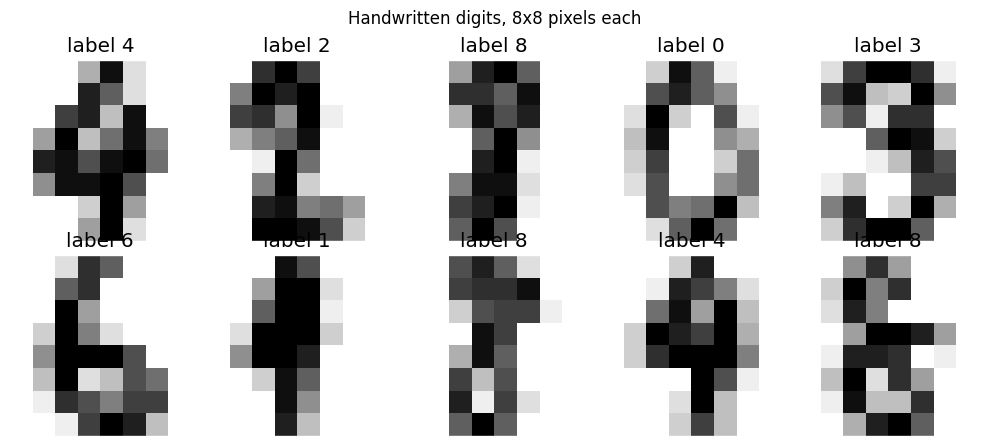

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, image, label in zip(ax.ravel(), X_train, y_train):
    a.imshow(image, cmap='gray_r')
    a.set_title(f'label {label}')
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)

plt.suptitle('Handwritten digits, 8x8 pixels each')
plt.tight_layout()
plt.show()

## What a convolution does

`conv_forward` slides each filter over the image. For every position it takes the 3x3 patch
sitting under the filter, multiplies it with the filter values and adds them up, giving one number.

On an 8x8 image a 3x3 filter fits in 6 positions across and 6 down, so each filter produces a 6x6
grid of responses called a **feature map**. With 16 filters the output is 6x6x16.

The loop runs over the 36 output positions rather than over the images. At each position it pulls
the same patch out of every image at once and multiplies it against all 16 filters in one matrix
product, so the whole batch is handled together.

In [4]:
def conv_forward(X, kernels, bias):
    n = len(X)
    f, kh, kw = kernels.shape
    out_h = X.shape[1] - kh + 1
    out_w = X.shape[2] - kw + 1

    out = np.zeros((n, out_h, out_w, f))
    flat_kernels = kernels.reshape(f, kh * kw)

    for i in range(out_h):
        for j in range(out_w):
            # the patch under the filter, taken from every image at once
            region = X[:, i:i + kh, j:j + kw].reshape(n, kh * kw)
            out[:, i, j, :] = region @ flat_kernels.T + bias

    return out

To show what that produces, the cell below applies two filters written by hand rather than learned.
The first has a positive column on the left and a negative one on the right, so it responds where
the image goes from bright to dark horizontally - a vertical edge. The second is the same idea
rotated, so it picks up horizontal edges.

The network is not given filters like these. It starts from random numbers and works out its own.

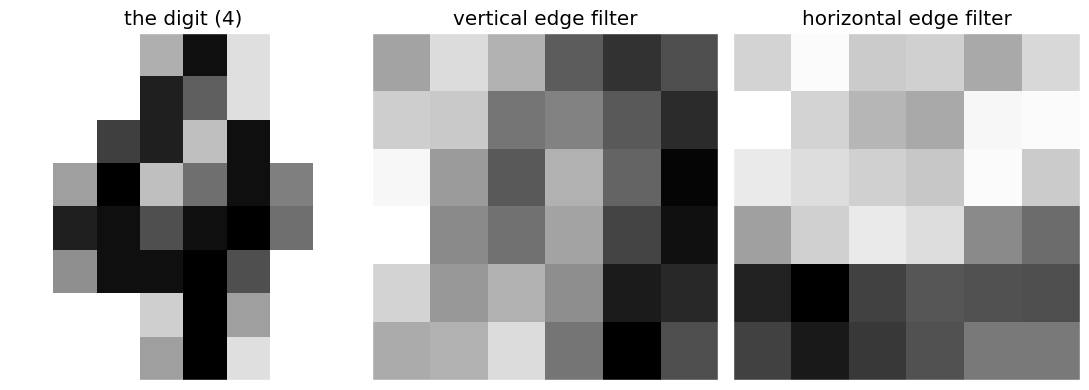

image shape : (1, 8, 8)
after conv  : (1, 6, 6, 2) (2 filters, each giving a 6x6 map)


In [5]:
vertical = np.array([[1., 0., -1.],
                     [1., 0., -1.],
                     [1., 0., -1.]])

horizontal = np.array([[1., 1., 1.],
                       [0., 0., 0.],
                       [-1., -1., -1.]])

hand_made = np.stack([vertical, horizontal])
digit = X_train[0:1]

maps = conv_forward(digit, hand_made, np.zeros(2))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
ax[0].imshow(digit[0], cmap='gray_r'); ax[0].set_title(f'the digit ({y_train[0]})')
ax[1].imshow(maps[0, :, :, 0], cmap='gray_r'); ax[1].set_title('vertical edge filter')
ax[2].imshow(maps[0, :, :, 1], cmap='gray_r'); ax[2].set_title('horizontal edge filter')

for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.tight_layout()
plt.show()

print('image shape :', digit.shape)
print('after conv  :', maps.shape, '(2 filters, each giving a 6x6 map)')

## Max pooling

Pooling shrinks a feature map by keeping only the strongest response in each small window. This
one takes 2x2 blocks and keeps the largest value, turning 6x6 into 3x3.

It does two things. It cuts the amount of data down, and it makes the answer less sensitive to
exactly where a stroke sits - shifting it by a pixel usually leaves the maximum of the block
unchanged.

In [6]:
def maxpool_forward(X):
    n, h, w, f = X.shape
    out = np.zeros((n, h // 2, w // 2, f))

    for i in range(h // 2):
        for j in range(w // 2):
            out[:, i, j, :] = X[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :].max(axis=(1, 2))

    return out


def softmax(scores):
    # subtract the largest score first so exp does not overflow
    e = np.exp(scores - scores.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

## Going backwards

Training needs the derivative of the loss with respect to every filter value, which means each
step has to be reversed.

`conv_backward` answers: if the output at some position should have been higher, how should the
filter change? Since that output was `patch . filter`, the derivative with respect to the filter is
just the patch itself, scaled by the gradient arriving at that position. The loop walks the same 36
positions as the forward pass and accumulates.

`maxpool_backward` is simpler. Only the largest value in each 2x2 block was used, so only that one
gets gradient and the other three get zero. `argmax` finds which position won. It matters that
exactly one is picked: when a block contains several equal values, which happens constantly here
because the blank background is all zeros, handing gradient to all of them would count it several
times over.

In [7]:
def conv_backward(X, kernels, dout):
    n = len(X)
    f, kh, kw = kernels.shape
    out_h, out_w = dout.shape[1], dout.shape[2]

    dk = np.zeros((f, kh * kw))
    db = np.zeros(f)

    for i in range(out_h):
        for j in range(out_w):
            region = X[:, i:i + kh, j:j + kw].reshape(n, kh * kw)
            dk += dout[:, i, j, :].T @ region
            db += dout[:, i, j, :].sum(axis=0)

    return dk.reshape(f, kh, kw), db


def maxpool_backward(X, dout):
    n, h, w, f = X.shape
    dX = np.zeros_like(X)
    rows, cols = np.meshgrid(np.arange(n), np.arange(f), indexing='ij')

    for i in range(h // 2):
        for j in range(w // 2):
            window = X[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :].reshape(n, 4, f)

            # only the winner of each block gets gradient, and only one winner
            winner = window.argmax(axis=1)
            mask = np.zeros_like(window)
            mask[rows, winner, cols] = 1

            dX[:, i * 2:i * 2 + 2, j * 2:j * 2 + 2, :] += (mask.reshape(n, 2, 2, f)
                                                           * dout[:, i:i + 1, j:j + 1, :])

    return dX

## The network

`__init__` creates the two sets of weights. The random values are scaled by `sqrt(2 / inputs)`,
which keeps the signal from growing or shrinking as it passes through the layers.

`forward` runs the image through convolution, ReLU, pooling, flattening and the dense layer,
keeping each intermediate result because the backward pass needs them.

`backward` starts from `probs - one hot`, which is the derivative of the softmax and the
cross-entropy loss taken together, then walks back through the same steps in reverse and subtracts
a small multiple of each gradient from the weights.

In [8]:
class CNN:
    def __init__(self, num_filters=16, learning_rate=0.1, seed=0):
        r = np.random.default_rng(seed)

        self.kernels = r.normal(0, np.sqrt(2 / 9), (num_filters, 3, 3))
        self.kernel_bias = np.zeros(num_filters)

        flat_size = 3 * 3 * num_filters
        self.weights = r.normal(0, np.sqrt(2 / flat_size), (flat_size, 10))
        self.bias = np.zeros(10)

        self.learning_rate = learning_rate

    def forward(self, X):
        self.X = X
        self.conv = conv_forward(X, self.kernels, self.kernel_bias)
        self.relu = np.maximum(0, self.conv)
        self.pool = maxpool_forward(self.relu)
        self.flat = self.pool.reshape(len(X), -1)
        self.scores = self.flat @ self.weights + self.bias
        return softmax(self.scores)

    def backward(self, probs, y):
        n = len(y)

        # derivative of softmax and cross-entropy together
        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1
        dscores /= n

        dweights = self.flat.T @ dscores
        dbias = dscores.sum(axis=0)

        dflat = dscores @ self.weights.T
        dpool = dflat.reshape(self.pool.shape)
        drelu = maxpool_backward(self.relu, dpool)
        dconv = drelu * (self.conv > 0)
        dkernels, dkernel_bias = conv_backward(self.X, self.kernels, dconv)

        self.weights -= self.learning_rate * dweights
        self.bias -= self.learning_rate * dbias
        self.kernels -= self.learning_rate * dkernels
        self.kernel_bias -= self.learning_rate * dkernel_bias

    def predict(self, X):
        return self.forward(X).argmax(axis=1)

## Checking the derivatives

The backward pass is the easy part to get wrong, and a mistake there does not raise an error - the
network just trains badly.

The check is to nudge one weight up by a tiny amount, nudge it down, and see how much the loss
actually moved. That measured slope should match what `backward` calculated. The cell compares a
few of each kind of weight.

In [9]:
def loss_of(net, X, y):
    probs = net.forward(X)
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()


check_net = CNN(num_filters=4, learning_rate=0.0)
Xb, yb = X_train[:12], y_train[:12]

# the gradients backward would compute
probs = check_net.forward(Xb)
dscores = probs.copy()
dscores[np.arange(len(yb)), yb] -= 1
dscores /= len(yb)
dweights = check_net.flat.T @ dscores
dflat = dscores @ check_net.weights.T
drelu = maxpool_backward(check_net.relu, dflat.reshape(check_net.pool.shape))
dkernels, _ = conv_backward(check_net.X, check_net.kernels, drelu * (check_net.conv > 0))

eps = 1e-5

def measured_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = loss_of(check_net, Xb, yb)
    param[index] = original - eps
    down = loss_of(check_net, Xb, yb)
    param[index] = original
    return (up - down) / (2 * eps)


print(f'{"weight":18s} {"from backward":>16s} {"measured":>16s}')
for index in [(2, 1, 0), (2, 2, 0), (0, 2, 1), (0, 0, 0)]:
    print(f'kernel {str(index):11s} {dkernels[index]:16.8f} {measured_slope(check_net.kernels, index):16.8f}')
for index in [(18, 3), (6, 3), (34, 3), (30, 3)]:
    print(f'dense  {str(index):11s} {dweights[index]:16.8f} {measured_slope(check_net.weights, index):16.8f}')

weight                from backward         measured
kernel (2, 1, 0)         0.68446575       0.68446575
kernel (2, 2, 0)         0.59162721       0.59162721
kernel (0, 2, 1)         0.48336707       0.48336707
kernel (0, 0, 0)         0.39665018       0.39665018
dense  (18, 3)           0.62057482       0.62057482
dense  (6, 3)            0.58101781       0.58101781
dense  (34, 3)           0.50196969       0.50196969
dense  (30, 3)           0.49337977       0.49337977


The two columns agree to eight decimal places, so the backward pass matches what the loss actually
does.

## Training

The loop goes over the training set 30 times. Each pass shuffles the data and works through it in
batches of 32, running `forward` then `backward` on each batch. Loss and accuracy on both the
training and test sets are recorded after every epoch.

In [10]:
def loss_and_accuracy(net, X, y, chunk=1000):
    total_loss = 0
    correct = 0
    for s in range(0, len(X), chunk):
        xb, yb = X[s:s + chunk], y[s:s + chunk]
        probs = net.forward(xb)
        total_loss += -np.log(probs[np.arange(len(yb)), yb] + 1e-12).sum()
        correct += (probs.argmax(axis=1) == yb).sum()
    return total_loss / len(X), correct / len(X)


net = CNN(num_filters=16, learning_rate=0.1)

train_loss, test_loss, train_acc, test_acc = [], [], [], []
batch_size = 32

for epoch in range(30):
    order = np.random.default_rng(epoch).permutation(len(X_train))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = net.forward(X_train[batch])
        net.backward(probs, y_train[batch])

    tl, ta = loss_and_accuracy(net, X_train, y_train)
    vl, va = loss_and_accuracy(net, X_test, y_test)
    train_loss.append(tl); train_acc.append(ta)
    test_loss.append(vl); test_acc.append(va)

    if (epoch + 1) % 5 == 0:
        print(f'epoch {epoch+1:2d}  train loss {tl:.4f} acc {ta:.4f}  |  test loss {vl:.4f} acc {va:.4f}')

print()
print(f'Final test accuracy: {test_acc[-1]:.4f}')

epoch  5  train loss 0.1250 acc 0.9635  |  test loss 0.1526 acc 0.9520


epoch 10  train loss 0.0770 acc 0.9798  |  test loss 0.1111 acc 0.9733


epoch 15  train loss 0.1023 acc 0.9673  |  test loss 0.1520 acc 0.9520


epoch 20  train loss 0.0540 acc 0.9867  |  test loss 0.1077 acc 0.9733


epoch 25  train loss 0.0510 acc 0.9862  |  test loss 0.0899 acc 0.9715


epoch 30  train loss 0.0407 acc 0.9887  |  test loss 0.0793 acc 0.9786

Final test accuracy: 0.9786


## Accuracy graphs

Loss on the left, accuracy on the right, with the training and test curves on the same axes. The
gap between them shows how much better the network does on digits it has already seen than on new
ones.

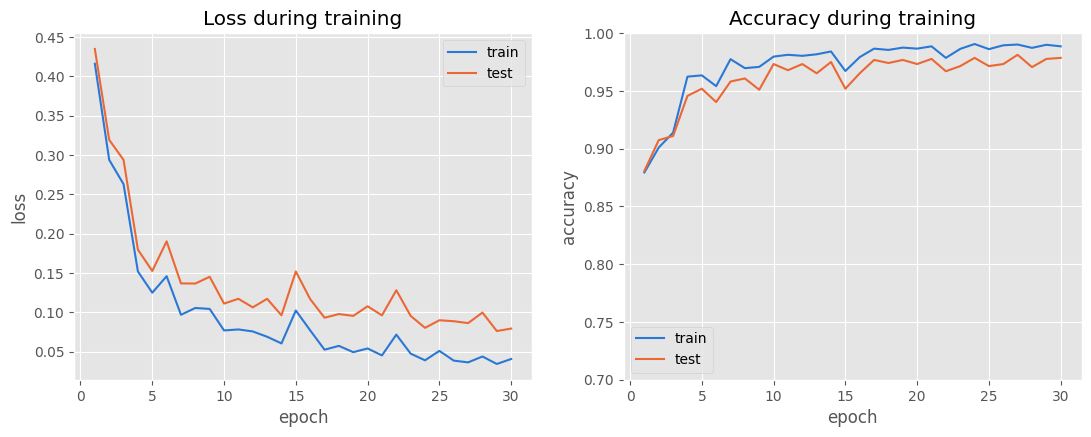

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(train_loss) + 1)

ax[0].plot(epochs, train_loss, color=blue, label='train')
ax[0].plot(epochs, test_loss, color=orange, label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[0].set_title('Loss during training')
ax[0].legend()

ax[1].plot(epochs, train_acc, color=blue, label='train')
ax[1].plot(epochs, test_acc, color=orange, label='test')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.7, 1.0)
ax[1].set_title('Accuracy during training')
ax[1].legend()

plt.show()

## The filters it learned

These are the 16 filters, drawn as 3x3 images. Light squares are positive weights and dark squares
negative. A filter responds most strongly to a patch that looks like it.

They were random at the start. Several have ended up with light and dark sides, which is an edge
detector of the sort written by hand earlier - the network arrived at it on its own because that is
what separates the digits.

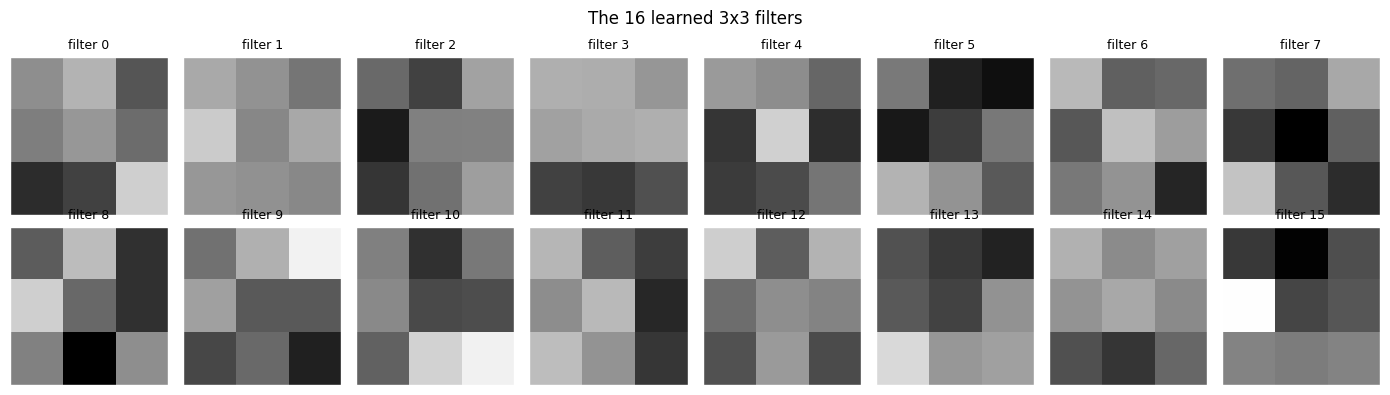

In [12]:
fig, ax = plt.subplots(2, 8, figsize=(14, 4))

limit = np.abs(net.kernels).max()
for a, kernel, index in zip(ax.ravel(), net.kernels, range(len(net.kernels))):
    a.imshow(kernel, cmap='gray_r', vmin=-limit, vmax=limit)
    a.set_title(f'filter {index}', fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The 16 learned 3x3 filters')
plt.tight_layout()
plt.show()

## What the filters see

The cell takes one digit and draws the feature map each learned filter produces after ReLU. Bright
areas are where that filter found what it responds to. Different filters light up on different
parts of the same digit.

Some panels come out blank. That is a filter which found nothing it responds to in this particular
digit, not a broken one - filter 1 is the most selective of the set and fires on under a tenth of
all positions across the test set, while filter 4 fires on almost nine tenths.

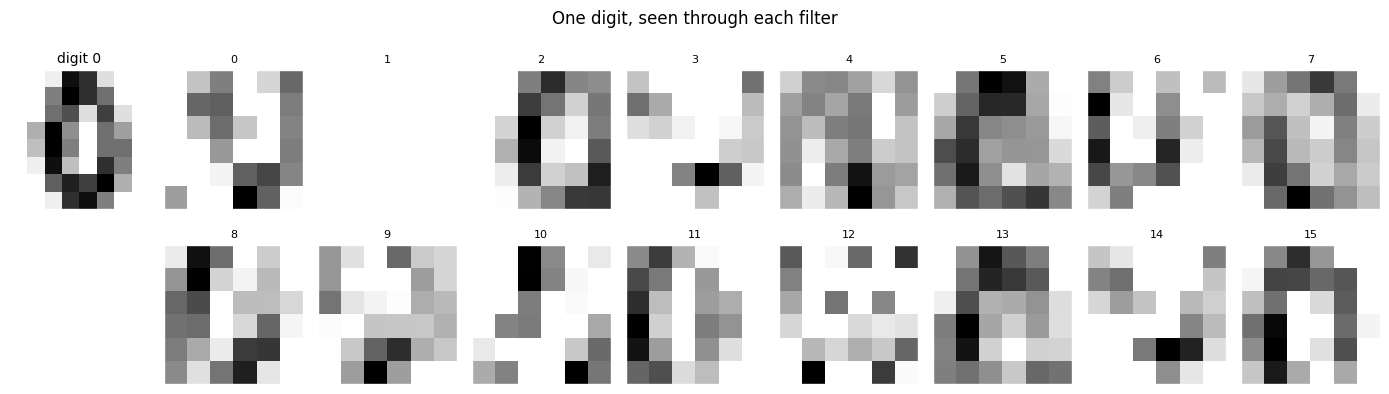

In [13]:
sample = X_test[0:1]
net.forward(sample)

fig = plt.figure(figsize=(14, 4.2))

a = plt.subplot(2, 9, 1)
a.imshow(sample[0], cmap='gray_r')
a.set_title(f'digit {y_test[0]}', fontsize=10)
a.set_xticks([]); a.set_yticks([]); a.grid(False)

for index in range(16):
    a = plt.subplot(2, 9, index + 2 + (index >= 8))
    a.imshow(net.relu[0, :, :, index], cmap='gray_r')
    a.set_title(f'{index}', fontsize=8)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('One digit, seen through each filter')
plt.tight_layout()
plt.show()

## Every stage of the forward pass

The panels above stop after ReLU. The cell below follows a single digit all the way through
instead, drawing what it looks like at each stage for four filters, with every panel at the same
number of figure inches per pixel so the shrinking is the size on the page.

The image starts at 8x8. A 3x3 filter with no padding fits in

$$H_{out} = H - k + 1 = 8 - 3 + 1 = 6$$

positions across and the same number down, because the filter cannot hang over the edge, so the
convolution output is 6x6. ReLU does not change the size - it only replaces every negative number
with zero, which is what the middle row shows against the same diverging colour scale as the row
above it: red is positive, blue is negative, and everything blue in the top row has gone white in
the middle one.

Pooling takes 2x2 blocks and keeps the largest of each, so

$$H_{pool} = \frac{6}{2} = 3$$

and the map ends up 3x3. Stacking the 16 of those and laying them out flat gives the 144 numbers
that the dense layer reads.

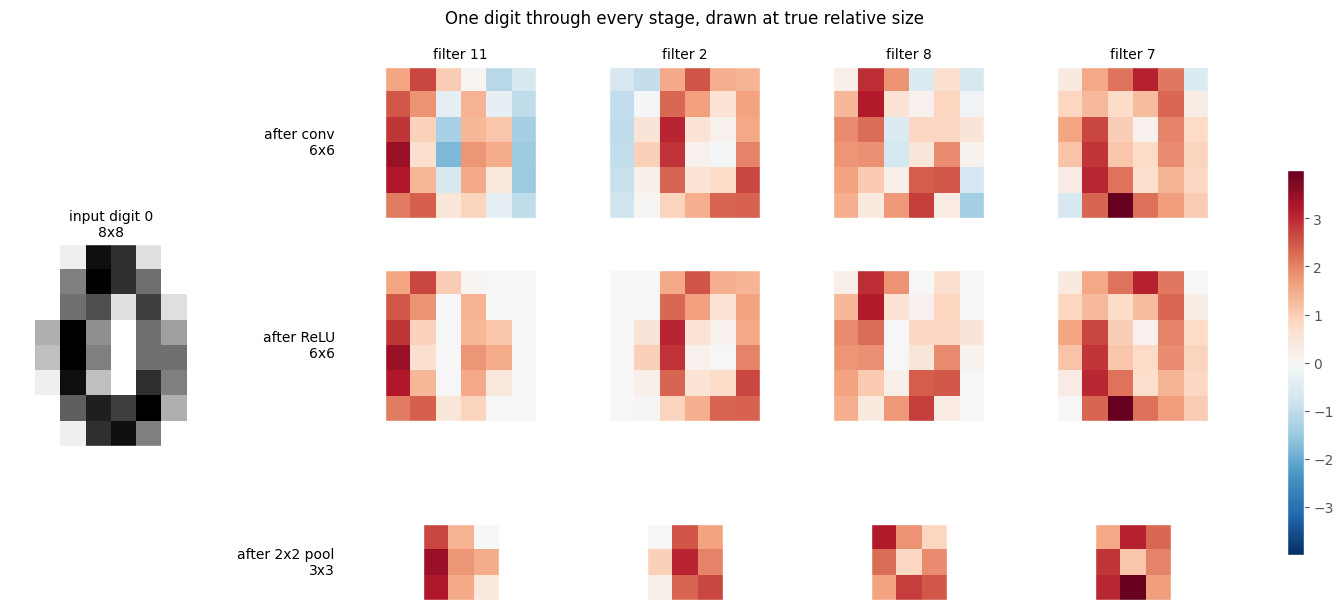

input       (8, 8)
after conv  (6, 6, 16)  8 - 3 + 1 = 6
after relu  (6, 6, 16)  unchanged
after pool  (3, 3, 16)  6 / 2 = 3
flattened   (144,)  3 * 3 * 16 = 144


In [14]:
sample = X_test[0:1]
sample_probs = net.forward(sample)

# the four filters that vary the most on this particular digit
picked = np.argsort(net.relu[0].std(axis=(0, 1)))[::-1][:4]

limit = np.abs(net.conv[0]).max()

fig = plt.figure(figsize=(14, 7))
scale, aspect = 0.018, 14 / 7

def place(cx, cy, pixels):
    w = pixels * scale
    h = w * aspect
    a = fig.add_axes([cx - w / 2, cy - h / 2, w, h])
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
    return a

rows = [0.79, 0.50, 0.19]
cols = [0.34, 0.50, 0.66, 0.82]

a = place(0.09, 0.50, 8)
a.imshow(sample[0], cmap='gray_r')
a.set_title(f'input digit {y_test[0]}\n8x8', fontsize=10)

for cx, index in zip(cols, picked):
    a = place(cx, rows[0], 6)
    drawn = a.imshow(net.conv[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a.set_title(f'filter {index}', fontsize=10)
    a = place(cx, rows[1], 6)
    a.imshow(net.relu[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a = place(cx, rows[2], 3)
    a.imshow(net.pool[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)

for y, text in zip(rows, ['after conv\n6x6', 'after ReLU\n6x6', 'after 2x2 pool\n3x3']):
    fig.text(0.25, y, text, ha='right', va='center', fontsize=10)

cax = fig.add_axes([0.93, 0.20, 0.012, 0.55])
fig.colorbar(drawn, cax=cax)

fig.suptitle('One digit through every stage, drawn at true relative size')
plt.show()

print('input      ', sample.shape[1:])
print('after conv ', net.conv.shape[1:], ' 8 - 3 + 1 = 6')
print('after relu ', net.relu.shape[1:], ' unchanged')
print('after pool ', net.pool.shape[1:], ' 6 / 2 = 3')
print('flattened  ', net.flat.shape[1:], ' 3 * 3 * 16 = 144')

Those 144 numbers are the whole of what the dense layer sees. The strip below draws them in the
order they are read, on the same red-and-blue scale, and every one of them is zero or positive
because they came through ReLU and then through a maximum.

The dense layer turns the strip into 10 scores, one per digit, and softmax turns those scores into
probabilities that add up to 1.

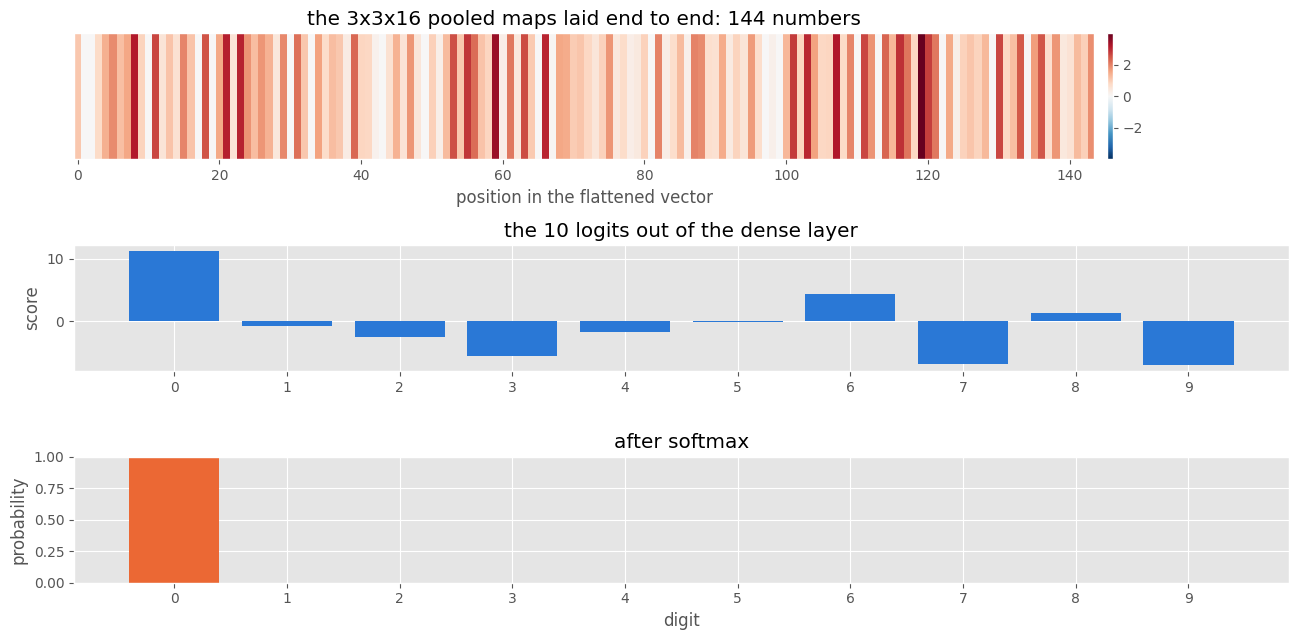

true label 0, predicted 0 with probability 0.9990


In [15]:
fig, ax = plt.subplots(3, 1, figsize=(13, 6.5))

strip = net.flat[0][None, :]
drawn = ax[0].imshow(strip, cmap='RdBu_r', vmin=-np.abs(strip).max(), vmax=np.abs(strip).max(),
                     aspect='auto')
ax[0].set_yticks([])
ax[0].set_xlabel('position in the flattened vector')
ax[0].set_title('the 3x3x16 pooled maps laid end to end: 144 numbers')
ax[0].grid(False)
fig.colorbar(drawn, ax=ax[0], pad=0.01)

ax[1].bar(range(10), net.scores[0], color=blue)
ax[1].set_xticks(range(10))
ax[1].set_ylabel('score')
ax[1].set_title('the 10 logits out of the dense layer')

ax[2].bar(range(10), sample_probs[0], color=orange)
ax[2].set_xticks(range(10))
ax[2].set_ylim(0, 1)
ax[2].set_xlabel('digit')
ax[2].set_ylabel('probability')
ax[2].set_title('after softmax')

plt.tight_layout()
plt.show()

print(f'true label {y_test[0]}, predicted {sample_probs[0].argmax()} '
      f'with probability {sample_probs[0].max():.4f}')

## Where the mistakes are

The table counts every test digit by what it really was against what the network said. The diagonal
is the correct answers.

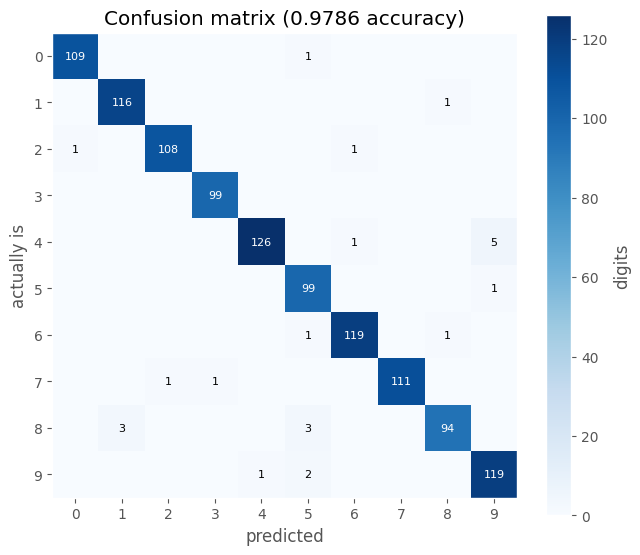

most common mix-ups:
  4 called 9: 5 times
  8 called 5: 3 times
  8 called 1: 3 times
  9 called 5: 2 times
  9 called 4: 1 times


In [16]:
predictions = net.predict(X_test)

table = np.zeros((10, 10), dtype=int)
for true, guess in zip(y_test, predictions):
    table[true, guess] += 1

plt.figure(figsize=(7.5, 6.5))
plt.imshow(table, cmap='Blues')
for i in range(10):
    for j in range(10):
        if table[i, j] > 0:
            plt.text(j, i, table[i, j], ha='center', va='center', fontsize=8,
                     color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('predicted'); plt.ylabel('actually is')
plt.title(f'Confusion matrix ({(predictions == y_test).mean():.4f} accuracy)')
plt.colorbar(label='digits')
plt.grid(False)
plt.show()

confused = [(table[i, j], i, j) for i in range(10) for j in range(10) if i != j]
print('most common mix-ups:')
for count, true, guess in sorted(confused, reverse=True)[:5]:
    print(f'  {true} called {guess}: {count} times')

## The ones it got wrong

Every test digit the network misread, with the true label and its guess. Most of them are genuinely
unclear at 8x8.

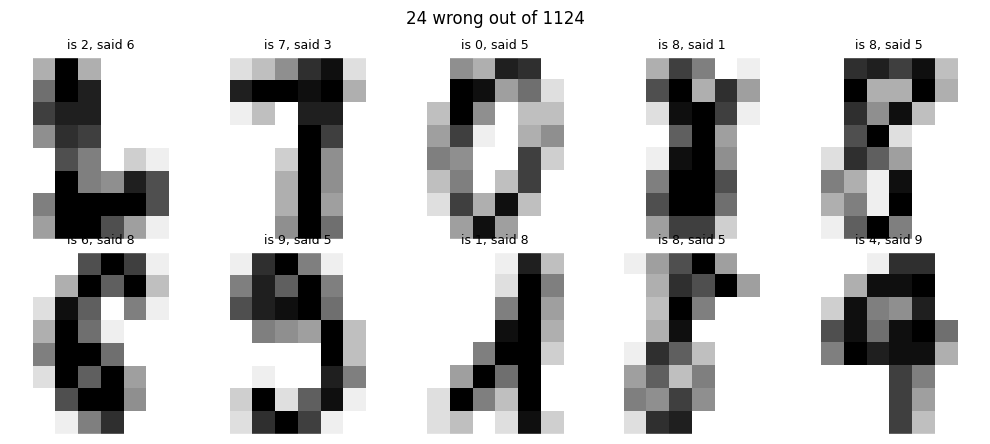

In [17]:
wrong = np.where(predictions != y_test)[0][:10]

fig, ax = plt.subplots(2, 5, figsize=(10, 4.5))

for a, index in zip(ax.ravel(), wrong):
    a.imshow(X_test[index], cmap='gray_r')
    a.set_title(f'is {y_test[index]}, said {predictions[index]}', fontsize=9)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

for a in ax.ravel()[len(wrong):]:
    a.axis('off')

plt.suptitle(f'{(predictions != y_test).sum()} wrong out of {len(y_test)}')
plt.tight_layout()
plt.show()

## Summary

- A convolution slides a small filter across the image and records how strongly it matches at each
  position, so the same pattern is recognised wherever it appears and a 3x3 filter costs 9 weights
  regardless of image size.
- Max pooling keeps the strongest response in each 2x2 block, shrinking the data and making the
  result less sensitive to a stroke moving by a pixel.
- The backward pass is the whole thing in reverse: the gradient for a filter is the patch it was
  looking at, and pooling passes gradient back only to the value that won its block.
- The finite-difference check confirms the hand-written derivatives agree with the loss to eight
  decimal places.
- With 16 filters and 1,610 weights it reaches **97.9%** on the held-out digits after 30 epochs,
  taking a couple of seconds to train.
- The filters were never told what to look for. Several came out as edge detectors on their own.

# Section 2 - colour images

Everything above ran on greyscale: one number per pixel, one 3x3 grid of weights per filter. A
colour photograph has three numbers per pixel, and a filter has to look at all three at once. That
is the one structural change made in this second half, and it is the only thing that has to be
rewritten.

The data is CIFAR-10, the only dataset in this repository that does not come from the UCI machine
learning repository. UCI's Python-importable collection has no RGB image data with an actual pixel
grid - its image datasets store per-region colour *means* rather than pixels - so a three-channel
convolution cannot be demonstrated on it.

CIFAR-10 is 60,000 photographs at 32x32 pixels in three channels, in ten classes.

The cell below fetches the archive into `data/cifar-10/` inside the repository and unpacks it, but
only if it is not there already; on any later run it uses the cached copy and downloads nothing. It
is about 170 MB, so `data/` is listed in `.gitignore` and never committed.

`urllib` fetches, `tarfile` unpacks and `pickle` reads the batch files, all from the standard
library.

In [18]:
import os
import time
import pickle
import tarfile
import urllib.request

section2_start = time.time()

url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
data_dir = '../data/cifar-10'
archive = os.path.join(data_dir, 'cifar-10-python.tar.gz')
batch_dir = os.path.join(data_dir, 'cifar-10-batches-py')

os.makedirs(data_dir, exist_ok=True)

if os.path.isdir(batch_dir):
    print('cached copy found, downloading nothing:', batch_dir)
else:
    print('no cached copy, downloading about 170 MB from', url)
    urllib.request.urlretrieve(url, archive)
    print('downloaded', os.path.getsize(archive), 'bytes')
    with tarfile.open(archive) as tar:
        tar.extractall(data_dir)
    print('unpacked into', batch_dir)

if os.path.exists(archive):
    print(f'archive on disk: {os.path.getsize(archive) / 1e6:.1f} MB')

cached copy found, downloading nothing: ../data/cifar-10/cifar-10-batches-py
archive on disk: 170.5 MB


Each batch file is a pickled dictionary holding 10,000 rows of 3,072 numbers. Those 3,072 are
32 x 32 x 3 laid out channel first, so `reshape(-1, 3, 32, 32)` recovers the image: index 0 is the
red plane, 1 green, 2 blue. Pixel values are 0 to 255 and dividing by 255 puts them between 0 and 1.

In [19]:
def load_batch(name):
    with open(os.path.join(batch_dir, name), 'rb') as f:
        return pickle.load(f, encoding='bytes')


train_batches = [load_batch(f'data_batch_{i}') for i in range(1, 6)]
test_batch = load_batch('test_batch')
meta = load_batch('batches.meta')

cifar_names = [n.decode() for n in meta[b'label_names']]

X_cifar_all = np.concatenate([b[b'data'] for b in train_batches]).reshape(-1, 3, 32, 32)
y_cifar_all = np.concatenate([np.array(b[b'labels']) for b in train_batches])
X_cifar_test_all = test_batch[b'data'].reshape(-1, 3, 32, 32)
y_cifar_test_all = np.array(test_batch[b'labels'])

print('training images:', X_cifar_all.shape)
print('test images    :', X_cifar_test_all.shape)
print('classes        :', cifar_names)

training images: (50000, 3, 32, 32)
test images    : (10000, 3, 32, 32)
classes        : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## The subset

A convolution written in NumPy loops over every output position in Python. On 32x32 images that is
900 positions per pass instead of the 36 on the digits, and there are 50,000 training images rather
than 4,496. Running the whole of CIFAR-10 that way would take hours, so a subset is used.

Four classes are kept - airplane, automobile, bird and cat - with 750 training images and 250 test
images each: 3,000 to train on and 1,000 held out. The classes are visually distinct enough that a
single convolutional layer has something to find, and the four counts are equal, so guessing the
most common class gives 25% and that is the number the result has to beat.

In [20]:
cifar_classes = [0, 1, 2, 3]
class_names = [cifar_names[c] for c in cifar_classes]


def take_subset(X, y, per_class, seed):
    r = np.random.default_rng(seed)
    chosen = []
    for c in cifar_classes:
        chosen.append(r.permutation(np.where(y == c)[0])[:per_class])
    chosen = r.permutation(np.concatenate(chosen))
    relabel = {c: i for i, c in enumerate(cifar_classes)}
    return X[chosen].astype(float) / 255.0, np.array([relabel[v] for v in y[chosen]])


X_col_train, y_col_train = take_subset(X_cifar_all, y_cifar_all, 750, 1)
X_col_test, y_col_test = take_subset(X_cifar_test_all, y_cifar_test_all, 250, 2)

# centre each channel on the training mean, which keeps the first layer's inputs near zero
channel_mean = X_col_train.mean(axis=(0, 2, 3), keepdims=True)
X_col_train_c = X_col_train - channel_mean
X_col_test_c = X_col_test - channel_mean

print('kept classes :', class_names)
print('train        :', X_col_train_c.shape, np.bincount(y_col_train))
print('test         :', X_col_test_c.shape, np.bincount(y_col_test))
print('channel means:', channel_mean.ravel().round(4))
print(f'majority-class baseline: {np.bincount(y_col_test).max() / len(y_col_test):.4f}')

kept classes : ['airplane', 'automobile', 'bird', 'cat']
train        : (3000, 3, 32, 32) [750 750 750 750]
test         : (1000, 3, 32, 32) [250 250 250 250]
channel means: [0.4964 0.4924 0.4718]
majority-class baseline: 0.2500


Ten of the training images, drawn in colour. They are photographs rather than centred pen strokes:
the object sits anywhere in the frame, at any size, against whatever background it was
photographed in.

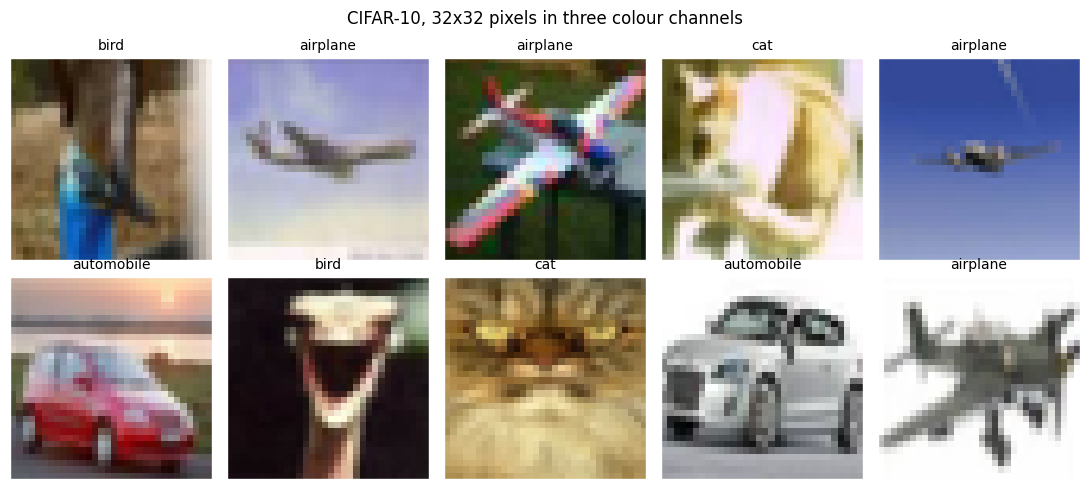

In [21]:
fig, ax = plt.subplots(2, 5, figsize=(11, 5))

for a, image, label in zip(ax.ravel(), X_col_train, y_col_train):
    a.imshow(np.transpose(image, (1, 2, 0)))
    a.set_title(class_names[label], fontsize=10)
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('CIFAR-10, 32x32 pixels in three colour channels')
plt.tight_layout()
plt.show()

## A filter that reads three channels

In the first half a filter was a 3x3 grid and the output at one position was the sum of nine
products. With three input channels the filter gains a channel axis and becomes 3x3x3, and the
output at one position is the sum over all three planes at once:

$$O[i,j,f] = \sum_{c=1}^{C_{in}}\sum_{a}\sum_{b} K_f[c,a,b]\,X[c,\,i+a,\,j+b] + \beta_f$$

Two things follow from that sum.

The first is the weight count. One filter holds $C_{in} \cdot k_h \cdot k_w$ numbers, which is
$1 \cdot 3 \cdot 3 = 9$ for greyscale and $3 \cdot 3 \cdot 3 = 27$ for RGB. A filter is three times
the size for the same 3x3 footprint.

The second is the shape of the output. The sum over $c$ collapses the channel axis, so a filter
that reads three planes still writes **one** 2-D feature map. Stacking $f$ filters gives an output
whose last axis is the number of filters, not the number of input channels. Three channels in, 16
maps out; the layer after this one would see 16 input channels and its filters would be
$16 \cdot 3 \cdot 3 = 144$ weights each.

The spatial rule is unchanged, because the filter still slides the same way:

$$H_{out} = H - k + 1 = 32 - 3 + 1 = 30, \qquad H_{pool} = \frac{30}{2} = 15$$

against the $8 \to 6 \to 3$ of the digits. The flattened vector is therefore
$15 \cdot 15 \cdot 16 = 3600$ numbers rather than 144.

`conv_forward_multi` is the same function as `conv_forward` with the channel axis folded into the
patch. The forward pass already worked by pulling out the patch under the filter, flattening it and
taking one matrix product against the flattened filters; the only change is that the patch now runs
over channels as well as rows and columns, so it flattens to `C_in * kh * kw` numbers instead of
`kh * kw`, and the filters flatten to match.

It was written as a second function rather than as a change to `conv_forward` so that the first
half of the notebook stays exactly as it was executed. It is a strict generalisation: with one
channel it does the same arithmetic, and the cell after next checks that against the original.

Images are held channel-first as `(n, C_in, 32, 32)` while feature maps stay channel-last as
`(n, 30, 30, f)`, which is what the pooling and dense code already expects, so `maxpool_forward`,
`maxpool_backward` and `softmax` are reused unchanged.

In [22]:
def conv_forward_multi(X, kernels, bias):
    n = len(X)
    f, c, kh, kw = kernels.shape
    out_h = X.shape[2] - kh + 1
    out_w = X.shape[3] - kw + 1

    out = np.zeros((n, out_h, out_w, f))
    flat_kernels = kernels.reshape(f, c * kh * kw)

    for i in range(out_h):
        for j in range(out_w):
            # the patch under the filter, across every channel, taken from every image at once
            region = X[:, :, i:i + kh, j:j + kw].reshape(n, c * kh * kw)
            out[:, i, j, :] = region @ flat_kernels.T + bias

    return out


def conv_backward_multi(X, kernels, dout):
    n = len(X)
    f, c, kh, kw = kernels.shape
    out_h, out_w = dout.shape[1], dout.shape[2]

    dk = np.zeros((f, c * kh * kw))
    db = np.zeros(f)

    for i in range(out_h):
        for j in range(out_w):
            region = X[:, :, i:i + kh, j:j + kw].reshape(n, c * kh * kw)
            # accumulates over images and positions, and over channels within the flattened patch
            dk += dout[:, i, j, :].T @ region
            db += dout[:, i, j, :].sum(axis=0)

    return dk.reshape(f, c, kh, kw), db

Handing the multi-channel version a single-channel input should reproduce the original function
exactly. The cell below runs both on the same random 8x8 images and prints the largest difference
between them.

In [23]:
r = np.random.default_rng(3)
grey_images = r.normal(size=(5, 8, 8))
grey_kernels = r.normal(size=(4, 3, 3))
grey_bias = r.normal(size=4)

one_channel = conv_forward(grey_images, grey_kernels, grey_bias)
generalised = conv_forward_multi(grey_images[:, None, :, :], grey_kernels[:, None, :, :], grey_bias)

print('conv_forward       ->', one_channel.shape)
print('conv_forward_multi ->', generalised.shape)
print('largest difference  :', np.abs(one_channel - generalised).max())

conv_forward       -> (5, 6, 6, 4)
conv_forward_multi -> (5, 6, 6, 4)
largest difference  : 0.0


## The colour network

The same five steps as before, with the sizes that follow from a 32x32x3 input:

```
32x32x3 image
  -> convolution, 16 filters of 3x3x3   -> 30x30x16
  -> ReLU
  -> max pooling 2x2                    -> 15x15x16
  -> flatten                            -> 3600
  -> dense layer                        -> 4
  -> softmax
```

That is 16 x 27 + 16 filter weights and 3600 x 4 + 4 dense weights, 14,836 in total. The random
scale is `sqrt(2 / 27)` for the filters because each one now sums 27 products rather than 9.

In [24]:
class ColourCNN:
    def __init__(self, num_filters=16, num_classes=4, learning_rate=0.05, seed=0):
        r = np.random.default_rng(seed)

        # 3 channels x 3 x 3 = 27 weights per filter
        self.kernels = r.normal(0, np.sqrt(2 / 27), (num_filters, 3, 3, 3))
        self.kernel_bias = np.zeros(num_filters)

        flat_size = 15 * 15 * num_filters
        self.weights = r.normal(0, np.sqrt(2 / flat_size), (flat_size, num_classes))
        self.bias = np.zeros(num_classes)

        self.learning_rate = learning_rate

    def forward(self, X):
        self.X = X
        self.conv = conv_forward_multi(X, self.kernels, self.kernel_bias)
        self.relu = np.maximum(0, self.conv)
        self.pool = maxpool_forward(self.relu)
        self.flat = self.pool.reshape(len(X), -1)
        self.scores = self.flat @ self.weights + self.bias
        return softmax(self.scores)

    def backward(self, probs, y):
        n = len(y)

        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1
        dscores /= n

        dweights = self.flat.T @ dscores
        dbias = dscores.sum(axis=0)

        dflat = dscores @ self.weights.T
        dpool = dflat.reshape(self.pool.shape)
        drelu = maxpool_backward(self.relu, dpool)
        dconv = drelu * (self.conv > 0)
        dkernels, dkernel_bias = conv_backward_multi(self.X, self.kernels, dconv)

        self.weights -= self.learning_rate * dweights
        self.bias -= self.learning_rate * dbias
        self.kernels -= self.learning_rate * dkernels
        self.kernel_bias -= self.learning_rate * dkernel_bias

    def predict(self, X):
        return self.forward(X).argmax(axis=1)


colour_net = ColourCNN(num_filters=16, learning_rate=0.05)
print('filter weights:', colour_net.kernels.shape, '=', colour_net.kernels.size, 'numbers')
print('dense weights :', colour_net.weights.shape, '=', colour_net.weights.size, 'numbers')

filter weights: (16, 3, 3, 3) = 432 numbers
dense weights : (3600, 4) = 14400 numbers


## Checking the derivatives again

`conv_backward_multi` accumulates over channels as well as over positions, which is a new place to
get an index wrong, so it gets the same finite-difference check as the greyscale version: nudge one
weight up by 1e-5, nudge it down, and compare the measured slope against the gradient the backward
pass produced.

The filter weights chosen are the centre weight of filter 0 in each of the three channels, which is
exactly the axis the new code added, plus the one filter weight with the largest gradient of all.
The four dense weights are the ones with the largest gradients.

In [25]:
colour_check = ColourCNN(num_filters=4, learning_rate=0.0)
Xc, yc = X_col_train_c[:12], y_col_train[:12]

probs = colour_check.forward(Xc)
dscores = probs.copy()
dscores[np.arange(len(yc)), yc] -= 1
dscores /= len(yc)
dweights = colour_check.flat.T @ dscores
dflat = dscores @ colour_check.weights.T
drelu = maxpool_backward(colour_check.relu, dflat.reshape(colour_check.pool.shape))
dkernels, _ = conv_backward_multi(colour_check.X, colour_check.kernels,
                                  drelu * (colour_check.conv > 0))

eps = 1e-5

def colour_slope(param, index):
    original = param[index]
    param[index] = original + eps
    up = loss_of(colour_check, Xc, yc)
    param[index] = original - eps
    down = loss_of(colour_check, Xc, yc)
    param[index] = original
    return (up - down) / (2 * eps)


biggest = np.argsort(np.abs(dweights).ravel())[::-1][:4]
dense_indices = [np.unravel_index(i, dweights.shape) for i in biggest]
largest_kernel = np.unravel_index(np.abs(dkernels).argmax(), dkernels.shape)

print(f'{"weight":24s} {"from backward":>16s} {"measured":>16s}')
for index in [(0, 0, 1, 1), (0, 1, 1, 1), (0, 2, 1, 1), largest_kernel]:
    print(f'kernel {str(index):17s} {dkernels[index]:16.8f} '
          f'{colour_slope(colour_check.kernels, index):16.8f}')
for index in dense_indices:
    print(f'dense  {str(index):17s} {dweights[index]:16.8f} '
          f'{colour_slope(colour_check.weights, index):16.8f}')

weight                      from backward         measured
kernel (0, 0, 1, 1)            0.02004092       0.02004092
kernel (0, 1, 1, 1)            0.03806483       0.03806483
kernel (0, 2, 1, 1)            0.03331421       0.03331421
kernel (0, 2, 2, 0)            0.06588589       0.06588589
dense  (877, 0)               -0.17336643      -0.17336643
dense  (225, 0)               -0.17187728      -0.17187728
dense  (869, 0)               -0.16933706      -0.16933706
dense  (849, 0)               -0.16683302      -0.16683302


The two columns agree to eight decimal places, including the three filter weights that sit at the
same position in the red, green and blue planes, so the sum over channels and its gradient are both
right.

## Training

Twenty passes over the 3,000 training images in batches of 32, with loss and accuracy on the
training and test sets recorded after each one. The elapsed time is printed as it goes.

In [26]:
train_start = time.time()

colour_net = ColourCNN(num_filters=16, learning_rate=0.05)

col_train_loss, col_test_loss, col_train_acc, col_test_acc = [], [], [], []
batch_size = 32

for epoch in range(20):
    order = np.random.default_rng(epoch).permutation(len(X_col_train_c))
    for s in range(0, len(order), batch_size):
        batch = order[s:s + batch_size]
        probs = colour_net.forward(X_col_train_c[batch])
        colour_net.backward(probs, y_col_train[batch])

    tl, ta = loss_and_accuracy(colour_net, X_col_train_c, y_col_train, chunk=500)
    vl, va = loss_and_accuracy(colour_net, X_col_test_c, y_col_test, chunk=500)
    col_train_loss.append(tl); col_train_acc.append(ta)
    col_test_loss.append(vl); col_test_acc.append(va)

    if (epoch + 1) % 4 == 0:
        print(f'epoch {epoch+1:2d}  train loss {tl:.4f} acc {ta:.4f}  |  '
              f'test loss {vl:.4f} acc {va:.4f}  [{time.time() - train_start:.0f}s]')

colour_train_time = time.time() - train_start

print()
print(f'Final test accuracy: {col_test_acc[-1]:.4f}')
print(f'Majority-class baseline: {np.bincount(y_col_test).max() / len(y_col_test):.4f}')
print(f'Training took {colour_train_time:.0f} seconds')

epoch  4  train loss 0.6394 acc 0.7557  |  test loss 0.7256 acc 0.7160  [12s]


epoch  8  train loss 0.5228 acc 0.8027  |  test loss 0.6896 acc 0.7330  [23s]


epoch 12  train loss 0.4577 acc 0.8330  |  test loss 0.7188 acc 0.7200  [34s]


epoch 16  train loss 0.3824 acc 0.8530  |  test loss 0.7050 acc 0.7210  [47s]


epoch 20  train loss 0.3049 acc 0.9060  |  test loss 0.7109 acc 0.7330  [58s]

Final test accuracy: 0.7330
Majority-class baseline: 0.2500
Training took 58 seconds


Loss on the left, accuracy on the right. The training and test curves separate after a few epochs
and keep separating: the network is memorising the 3,000 training photographs faster than it is
learning anything that carries over to new ones.

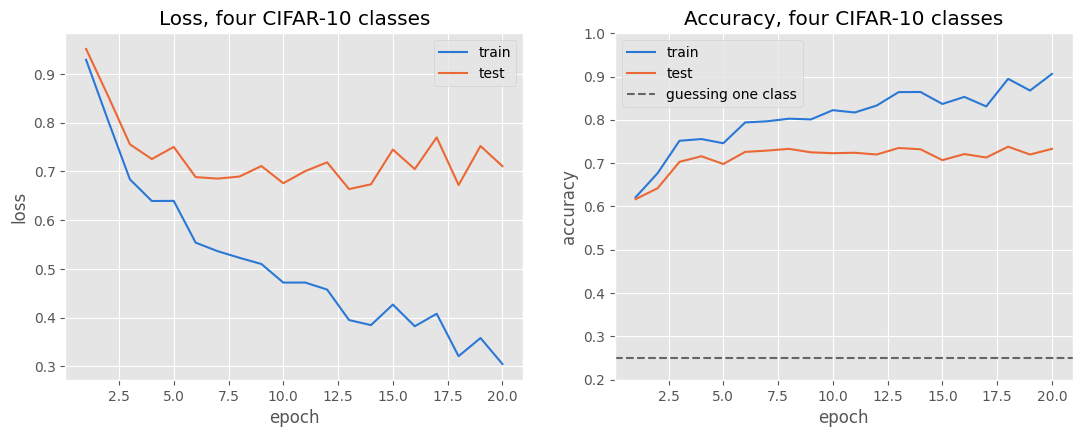

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, len(col_train_loss) + 1)

ax[0].plot(epochs, col_train_loss, color=blue, label='train')
ax[0].plot(epochs, col_test_loss, color=orange, label='test')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[0].set_title('Loss, four CIFAR-10 classes')
ax[0].legend()

ax[1].plot(epochs, col_train_acc, color=blue, label='train')
ax[1].plot(epochs, col_test_acc, color=orange, label='test')
ax[1].axhline(0.25, color='0.4', linestyle='--', label='guessing one class')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy')
ax[1].set_ylim(0.2, 1.0)
ax[1].set_title('Accuracy, four CIFAR-10 classes')
ax[1].legend()

plt.show()

## The filters, in colour

A greyscale filter had 9 numbers and was drawn as a 3x3 patch of light and dark. A colour filter has
27, three of them per pixel, which is exactly what an RGB image is - so each filter draws directly
as a tiny 3x3 colour patch, with no choice of colour map involved. Each is scaled to fill the 0 to 1
range before drawing, since the raw weights are small and signed.

The row underneath splits the same filters into their red, green and blue planes on a shared
diverging scale, so the sign of each weight is visible.

A filter splits cleanly into two parts. Averaging its three channel planes gives one 3x3 grid, and
copying that average back into all three channels gives the part of the filter that treats red,
green and blue alike - a brightness detector, exactly what a greyscale filter is. Whatever is left
over puts different weights on different channels, so it responds to one colour against another and
ignores brightness. The two parts are perpendicular, so the squared weights split between them and
the share sitting in each is a number.

The cell prints that share for every filter, along with the three channel sums, and calls a filter
a brightness detector when more than half its weight is in the brightness part.

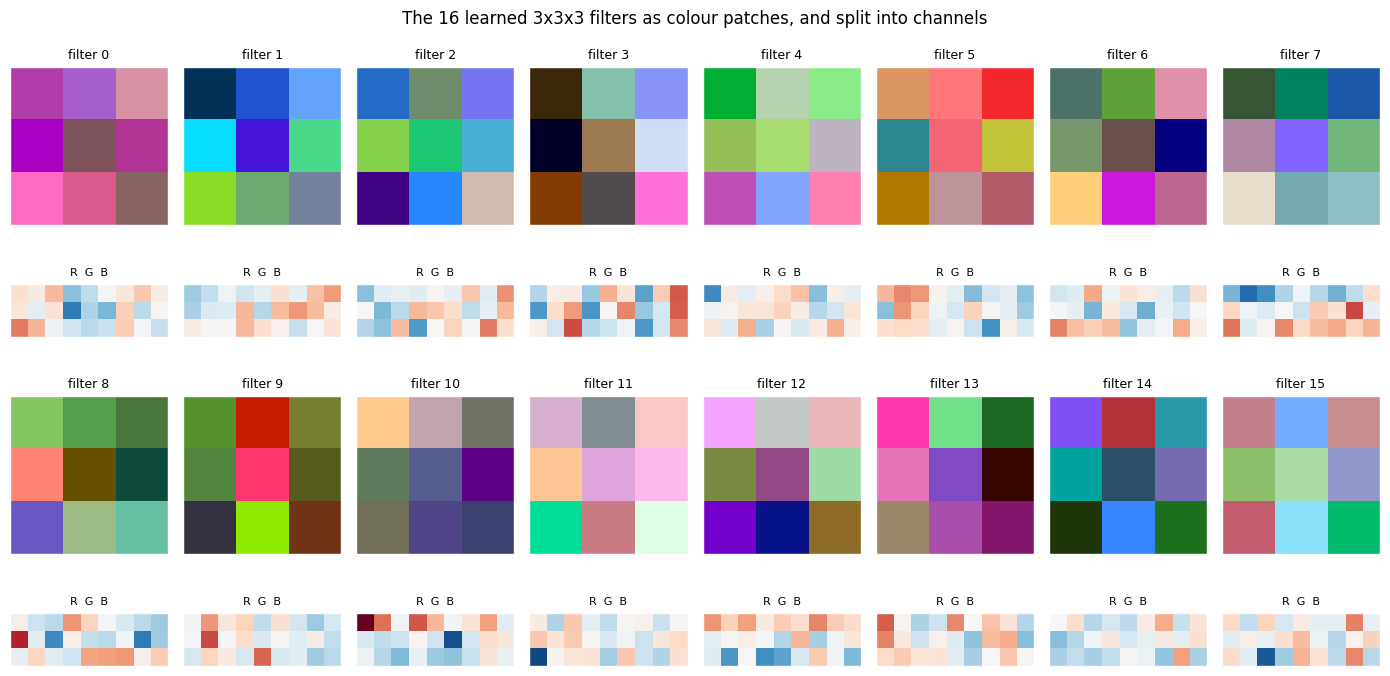

filter       sum R     sum G     sum B   brightness   responds to
0           1.8972   -3.5037    0.5541        0.230   colour opposition
1          -1.4323    0.9483    1.6571        0.241   colour opposition
2          -2.1109    0.3140    1.5806        0.244   colour opposition
3           0.4744   -0.6382    0.1140        0.795   brightness
4          -0.2394    0.6372   -0.3924        0.344   colour opposition
5           2.4721   -0.9083   -2.2590        0.148   colour opposition
6           0.6693   -0.7162   -0.0100        0.482   colour opposition
7          -1.6848    0.4935    1.3945        0.602   brightness
8          -0.4652    1.0100   -1.4199        0.517   brightness
9           1.5926    0.5219   -2.1371        0.177   colour opposition
10          0.1393   -1.1929    0.4607        0.648   brightness
11         -0.0349   -0.5198   -0.5337        0.471   colour opposition
12          0.4695   -0.9281    0.5606        0.618   brightness
13          1.5696   -0.6317    0

In [28]:
fig, ax = plt.subplots(4, 8, figsize=(14, 7.5))

limit = np.abs(colour_net.kernels).max()
channel_labels = ['R', 'G', 'B']

for index in range(16):
    col = index % 8
    block = (index // 8) * 2

    kernel = np.transpose(colour_net.kernels[index], (1, 2, 0))
    shown = (kernel - kernel.min()) / (kernel.max() - kernel.min())

    a = ax[block, col]
    a.imshow(shown)
    a.set_title(f'filter {index}', fontsize=9)

    a = ax[block + 1, col]
    a.imshow(np.concatenate(colour_net.kernels[index], axis=1), cmap='RdBu_r',
             vmin=-limit, vmax=limit)
    a.set_title('R  G  B', fontsize=8)

for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

plt.suptitle('The 16 learned 3x3x3 filters as colour patches, and split into channels')
plt.tight_layout()
plt.show()

def brightness_share(kernel):
    # the part of the filter that weights all three channels identically
    average = kernel.mean(axis=0)
    return 3 * (average ** 2).sum() / (kernel ** 2).sum()


channel_totals = colour_net.kernels.sum(axis=(2, 3))
shares = np.array([brightness_share(k) for k in colour_net.kernels])

print(f'{"filter":8s} {"sum R":>9s} {"sum G":>9s} {"sum B":>9s} {"brightness":>12s}   responds to')
for index, (red, green, blue_) in enumerate(channel_totals):
    kind = 'brightness' if shares[index] > 0.5 else 'colour opposition'
    print(f'{index:<8d} {red:9.4f} {green:9.4f} {blue_:9.4f} {shares[index]:12.3f}   {kind}')

print()
print('mostly brightness       :', int((shares > 0.5).sum()))
print('mostly colour opposition:', int((shares <= 0.5).sum()))
print(f'brightness share, smallest {shares.min():.3f}, largest {shares.max():.3f}')

## One photograph, three channels

Before following an image through the layers, here is what the layers are handed: the picture as a
colour image, then the same picture as the three separate planes the convolution actually reads.
Each plane is a 32x32 grid of single numbers, and it is only the filter summing across all three
that puts them back together.

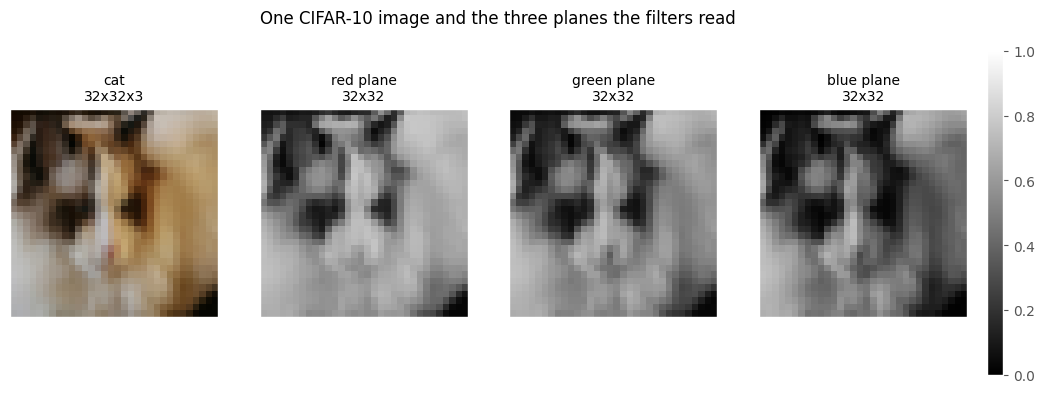

In [29]:
colour_sample = X_col_test[0:1]
colour_sample_c = X_col_test_c[0:1]

fig, ax = plt.subplots(1, 4, figsize=(13, 4.2))

ax[0].imshow(np.transpose(colour_sample[0], (1, 2, 0)))
ax[0].set_title(f'{class_names[y_col_test[0]]}\n32x32x3', fontsize=10)

for index, name in enumerate(['red plane', 'green plane', 'blue plane']):
    drawn = ax[index + 1].imshow(colour_sample[0, index], cmap='gray', vmin=0, vmax=1)
    ax[index + 1].set_title(f'{name}\n32x32', fontsize=10)

for a in ax:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)

fig.colorbar(drawn, ax=list(ax), pad=0.02, fraction=0.03)
plt.suptitle('One CIFAR-10 image and the three planes the filters read')
plt.show()

## The same walk through the layers, in colour

This is the figure from the first half repeated on a colour photograph, at the same figure inches
per pixel throughout, so the $32 \to 30 \to 15$ shrinking is again the size on the page. The input
is 32x32x3 but every feature map is a single 2-D grid, because each filter summed its 27 weights
across the three planes down to one number per position.

The top row is the raw convolution output on a diverging scale, the middle row is the same after
ReLU with everything negative flattened to white, and the bottom row is after 2x2 pooling.

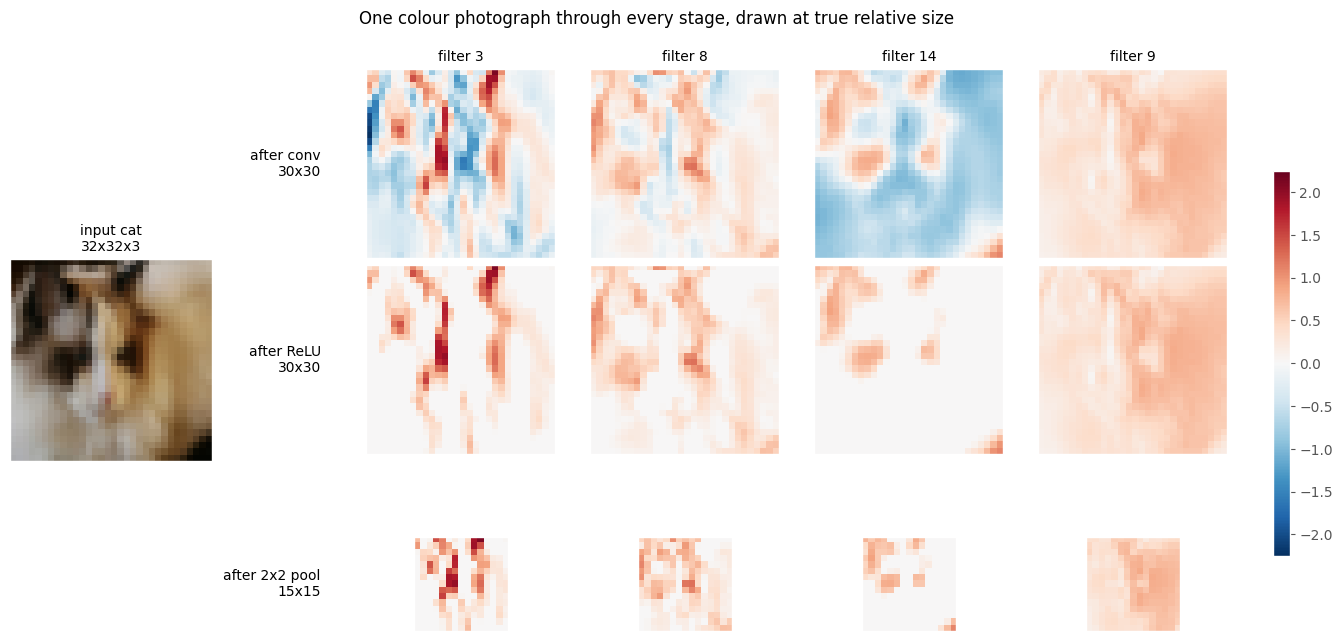

input       (3, 32, 32)  3 channels
after conv  (30, 30, 16)  32 - 3 + 1 = 30, one map per filter
after relu  (30, 30, 16)  unchanged
after pool  (15, 15, 16)  30 / 2 = 15
flattened   (3600,)  15 * 15 * 16 = 3600

filters drawn above: [3, 8, 14, 9]
  filter  3  sums R  0.4744  G -0.6382  B  0.1140   brightness share 0.795   brightness
  filter  8  sums R -0.4652  G  1.0100  B -1.4199   brightness share 0.517   brightness
  filter 14  sums R -2.1893  G -0.9467  B  0.1409   brightness share 0.424   colour opposition
  filter  9  sums R  1.5926  G  0.5219  B -2.1371   brightness share 0.177   colour opposition


In [30]:
colour_probs = colour_net.forward(colour_sample_c)
picked = np.argsort(colour_net.relu[0].std(axis=(0, 1)))[::-1][:4]

limit = np.abs(colour_net.conv[0]).max()

fig = plt.figure(figsize=(14, 7))
scale, aspect = 0.0045, 14 / 7

def place(cx, cy, pixels):
    w = pixels * scale
    h = w * aspect
    a = fig.add_axes([cx - w / 2, cy - h / 2, w, h])
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
    return a

rows = [0.76, 0.48, 0.16]
cols = [0.36, 0.52, 0.68, 0.84]

a = place(0.11, 0.48, 32)
a.imshow(np.transpose(colour_sample[0], (1, 2, 0)))
a.set_title(f'input {class_names[y_col_test[0]]}\n32x32x3', fontsize=10)

for cx, index in zip(cols, picked):
    a = place(cx, rows[0], 30)
    drawn = a.imshow(colour_net.conv[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a.set_title(f'filter {index}', fontsize=10)
    a = place(cx, rows[1], 30)
    a.imshow(colour_net.relu[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)
    a = place(cx, rows[2], 15)
    a.imshow(colour_net.pool[0, :, :, index], cmap='RdBu_r', vmin=-limit, vmax=limit)

for y, text in zip(rows, ['after conv\n30x30', 'after ReLU\n30x30', 'after 2x2 pool\n15x15']):
    fig.text(0.26, y, text, ha='right', va='center', fontsize=10)

cax = fig.add_axes([0.94, 0.20, 0.012, 0.55])
fig.colorbar(drawn, cax=cax)

fig.suptitle('One colour photograph through every stage, drawn at true relative size')
plt.show()

print('input      ', colour_sample_c.shape[1:], ' 3 channels')
print('after conv ', colour_net.conv.shape[1:], ' 32 - 3 + 1 = 30, one map per filter')
print('after relu ', colour_net.relu.shape[1:], ' unchanged')
print('after pool ', colour_net.pool.shape[1:], ' 30 / 2 = 15')
print('flattened  ', colour_net.flat.shape[1:], ' 15 * 15 * 16 = 3600')
print()
print('filters drawn above:', list(picked))
for index in picked:
    red, green, blue_ = colour_net.kernels[index].sum(axis=(1, 2))
    share = brightness_share(colour_net.kernels[index])
    print(f'  filter {index:2d}  sums R {red:7.4f}  G {green:7.4f}  B {blue_:7.4f}   '
          f'brightness share {share:.3f}   '
          f'{"brightness" if share > 0.5 else "colour opposition"}')

The output side, drawn the same way as for the digit: the 3,600 flattened numbers as a strip, then
the four logits and the four probabilities. The strip is 25 times longer than the digit's 144
because the images are 16 times larger in area.

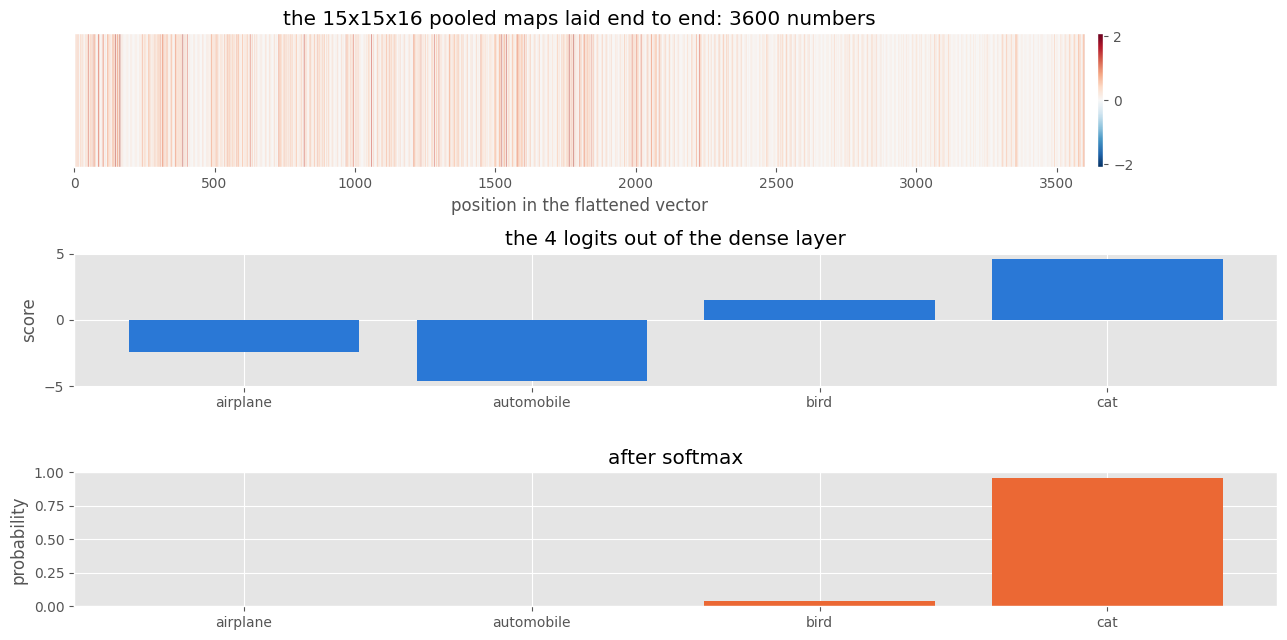

true class cat, predicted cat with probability 0.9564


In [31]:
fig, ax = plt.subplots(3, 1, figsize=(13, 6.5))

strip = colour_net.flat[0][None, :]
drawn = ax[0].imshow(strip, cmap='RdBu_r', vmin=-np.abs(strip).max(), vmax=np.abs(strip).max(),
                     aspect='auto')
ax[0].set_yticks([])
ax[0].set_xlabel('position in the flattened vector')
ax[0].set_title('the 15x15x16 pooled maps laid end to end: 3600 numbers')
ax[0].grid(False)
fig.colorbar(drawn, ax=ax[0], pad=0.01)

ax[1].bar(range(4), colour_net.scores[0], color=blue)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(class_names)
ax[1].set_ylabel('score')
ax[1].set_title('the 4 logits out of the dense layer')

ax[2].bar(range(4), colour_probs[0], color=orange)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels(class_names)
ax[2].set_ylim(0, 1)
ax[2].set_ylabel('probability')
ax[2].set_title('after softmax')

plt.tight_layout()
plt.show()

print(f'true class {class_names[y_col_test[0]]}, '
      f'predicted {class_names[colour_probs[0].argmax()]} '
      f'with probability {colour_probs[0].max():.4f}')

## Where the colour mistakes are

The same table as for the digits, over the four classes.

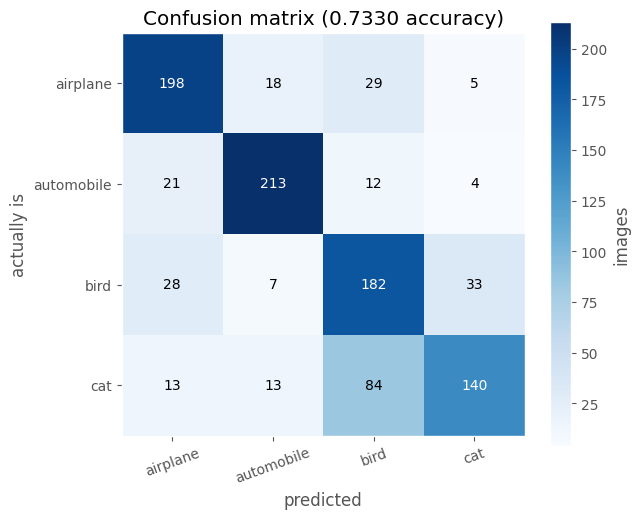

most common mix-ups:
  cat called bird: 84 times
  bird called cat: 33 times
  airplane called bird: 29 times
  bird called airplane: 28 times

total time for this section: 60 seconds


In [32]:
colour_predictions = colour_net.predict(X_col_test_c)

table = np.zeros((4, 4), dtype=int)
for true, guess in zip(y_col_test, colour_predictions):
    table[true, guess] += 1

plt.figure(figsize=(6.5, 5.5))
plt.imshow(table, cmap='Blues')
for i in range(4):
    for j in range(4):
        plt.text(j, i, table[i, j], ha='center', va='center', fontsize=10,
                 color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(4), class_names, rotation=20)
plt.yticks(range(4), class_names)
plt.xlabel('predicted'); plt.ylabel('actually is')
plt.title(f'Confusion matrix ({(colour_predictions == y_col_test).mean():.4f} accuracy)')
plt.colorbar(label='images')
plt.grid(False)
plt.show()

confused = [(table[i, j], i, j) for i in range(4) for j in range(4) if i != j]
print('most common mix-ups:')
for count, true, guess in sorted(confused, reverse=True)[:4]:
    print(f'  {class_names[true]} called {class_names[guess]}: {count} times')

print()
print(f'total time for this section: {time.time() - section2_start:.0f} seconds')

## What the number means

Four CIFAR-10 classes, 3,000 training photographs, one convolutional layer: the network lands in
the low seventies against a 25% baseline for guessing a single class. The digits network reached
97.9%. The gap is not a fault in the code - the check above shows the derivatives are exact, and
the same arithmetic produced both numbers.

The two problems are not comparable in difficulty.

- A digit is a centred pen stroke on a blank background at 8x8. Every training image is the same
  object, drawn the same size, in the same place, with nothing else in the frame.
- A CIFAR-10 image is a photograph. The cat can be anywhere in the frame, at any size, facing any
  direction, in any lighting, in front of any background, and half the pixels are usually
  background rather than object. Two photographs of the same class often share no pixel values at
  all.
- The network is one convolutional layer. It can find 3x3 patterns and where in a 15x15 grid they
  occurred, and nothing beyond that. A 3x3 filter spans a tenth of the image width; recognising an
  animal needs features built out of features, which is what stacking convolutional layers is for.
- 3,000 images across four classes is 750 examples each, which is why the training and test curves
  separate so early.

Turning any of those knobs would raise the number, and none of them would be about convolutions
over colour, which is what this section set out to show.

## Summary of the colour section

- A filter over $C_{in}$ channels holds $C_{in} \cdot k_h \cdot k_w$ weights - 9 for greyscale,
  27 for RGB - and sums across all of them at each position.
- Because that sum collapses the channel axis, each filter still writes one 2-D map, so the output
  has as many channels as there are filters regardless of how many channels went in.
- The spatial rules are untouched by the extra channels: 32 - 3 + 1 = 30 after the convolution and
  30 / 2 = 15 after pooling, the same arithmetic that gave 8 -> 6 -> 3 on the digits.
- `conv_forward_multi` is `conv_forward` with the channel axis folded into the flattened patch, and
  it reproduces the original exactly on single-channel input.
- The finite-difference check agrees to eight decimal places on filter weights in all three colour
  planes, so the backward pass sums the gradient over channels correctly.
- Drawn as images, the learned filters are small colour patches. Splitting each one into the part
  that weights all three channels alike and the part that does not puts ten of the sixteen mostly
  in the second, so this network leaned towards colour oppositions where the greyscale filters had
  only brightness edges available to them.
- On four CIFAR-10 classes it reaches roughly 73% against a 25% baseline, well short of the 97.9%
  on digits, because 32x32 colour photographs with varied pose, background and lighting are a far
  harder problem than centred 8x8 digits and this is a single convolutional layer.